In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr
from matplotlib.path import Path
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize
from matplotlib.colors import to_rgba
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import PathPatch, Rectangle
from scipy.spatial import cKDTree
from scipy.interpolate import interp1d
from pyhdf.SD import SD, SDC
from matplotlib.widgets import Button

from hapi import *

VERBOSE = False

from pylab import show,plot,subplot,xlim,ylim,title,legend,xlabel,ylabel

from scipy.signal import correlate, find_peaks, savgol_filter, peak_widths
from scipy import signal

#File Parsing and Handling
import glob
import os

%matplotlib widget

# Helper Functions

In [7]:
#Extracts name from file path
def extract_name(file):
    base = os.path.basename(file)#Returns final component of a pathname
    name, ext = os.path.splitext(base)
    return name

def get_wn_range_and_intensities(filepath):
    intensities = []
    with open(filepath, 'r') as f:
        first_line = f.readline()
        tokens = first_line.split()
        floats = []
        for t in tokens:
            try:
                floats.append(float(t))
            except:
                pass
        wn_start, wn_end = floats[0], floats[1]
        for line in f:
            for val in line.split():
                try:
                    intensity = float(val.replace('D','E'))
                    intensity = np.clip(intensity, 1e-25, None)  # avoid log(0)
                    intensities.append(intensity)
                except ValueError:
                    pass
    return wn_start, wn_end, np.array(intensities)

def load_cross_section_file(filepath):
    """
    For lbl files
    """
    data = np.genfromtxt(filepath, delimiter=' ', comments='#')
    wn_grid = data[:,0]
    intensities = data[:,1]
    wavelength_grid = 1e4 / wn_grid
    return wavelength_grid, intensities

def load_intensity_hapi(molecule_formula):
    """
    For HAPI database
    """
    nu = getColumn(molecule_formula, 'nu')  # Wavenumber in cm^-1
    intensity = getColumn(molecule_formula, 'sw')  # Intensity in cm/molecule
    wavelength = 1e4 / nu  # Convert to microns
    wl_step = wavelength[0] - wavelength[1]
    return wavelength, intensity, wl_step

def generate_transmittance_absorbance(
    table_name, molecule_number,
    wavelength_min, wavelength_max,
    dwn,              # cm^-1 sampling step
    T=296.0, p=1.0,        # K, atm
    L_cm=10.0              # path length in cm
):
    iso = 1
    wn_min = 1e4 / wavelength_max
    wn_max = 1e4 / wavelength_min

    # Download the line list (cached locally by HAPI)
    fetch(table_name, molecule_number, iso, wn_min, wn_max);

    # Absorption coefficient alpha(wn) in cm^-1 on a uniform wn grid
    # wn_grid, alpha = absorptionCoefficient_Voigt(
    #     SourceTables=table_name,
    #     WavenumberRange=(wn_min, wn_max),
    #     WavenumberStep=dwn,
    #     Environment={'T': T, 'p': p}
    # )

    wn_grid, alpha = absorptionCoefficient_Voigt(
    SourceTables=table_name,
    WavenumberRange=(wn_min, wn_max),
    WavenumberStep=dwn,
    Environment={'T': T, 'p': p}
    );

    # scale by column density (molecules/cm^2)
    N = 2.5e19  # example; choose based on your scenario
    tau = alpha * N


    # Beer–Lambert
    # absorbance = np.exp(-alpha * L_cm)
    transmittance = np.exp(-tau)

    # Base-10 absorbance
    absorbance = -np.log10(transmittance)  # = alpha*L_cm/ln(10)

    wavelength_grid = 1e4 / wn_grid

    #Compute spectral resolution
    dnu = np.median(np.diff(wn_grid))  # cm^-1
    R_nu = wn_grid / dnu               # dimensionless

    return wavelength_grid, wn_grid, transmittance, absorbance, R_nu

def generate_absorbance_library(molecule_indices, lam_min_um, lam_max_um, dwn):
    """
    Generate absorbance spectra once per molecule.

    Returns:
        spectra[molecule] = {
            "wavelength": np.ndarray (µm),
            "wavenumber": np.ndarray (cm^-1),
            "absorbance": np.ndarray,
            "spec_res": float
        }
    """
    spectra = {}

    for molecule, idx in molecule_indices.items():
        print("Trying:", molecule, idx)
        wavelength, wn_grid, trans, absorbance, spec_res = (
            generate_transmittance_absorbance(
                molecule, idx, lam_min_um, lam_max_um, dwn
            )
        )

        spectra[molecule] = {
            "wavelength": np.asarray(wavelength),
            "wavenumber": np.asarray(wn_grid),
            "absorbance": np.asarray(absorbance),
            "spec_res": spec_res,
        }

        print(
            f"{molecule}: "
            f"λ = {spectra[molecule]['wavelength'].min():.3f}–{spectra[molecule]['wavelength'].max():.3f} µm, "
            f"abs max = {spectra[molecule]['absorbance'].max():.3e}"
        )

    return spectra


#Normalizing Spectrum

def normalize_spectrum(spectrum, eps=1e-30):
    s0 = spectrum - np.mean(spectrum)
    n0 = np.linalg.norm(s0)
    if n0 < eps:
        return np.zeros_like(spectrum)
    return (s0 / n0)

def highpass(spectrum, window=51, polyorder=4): #Fits a polynomial to each point, considering the surrounding points in a set window 
    trend = savgol_filter(spectrum, window_length=window, polyorder=polyorder)
    return spectrum - trend


#Add Poisson Noise based on SNR
def add_poisson_noise_snr(T, snr):
    noise = np.random.normal(0, 1/snr, size=T.shape) #Mean = 0, Standard Deviation = 1/SNR, Normal indicates gaussian distribution, size=T.shape ensures noise array matches T array in size
    return T + noise

def find_troughs_wn(wn, y, smooth=False, window=31, poly=3,
                    prominence=None, distance=None):
    """
    Return sorted wavenumbers (cm^-1) where y has troughs (local minima).
    """
    wn = np.asarray(wn)
    y = np.asarray(y)

    # Ensure increasing wn
    if wn[0] > wn[-1]:
        wn = wn[::-1]
        y = y[::-1]

    # Optional smoothing (helps a lot with noisy spectra)
    if smooth:
        window = int(window)
        if window % 2 == 0:
            window += 1
        window = min(window, len(y) - (1 - len(y) % 2))
        if window >= 5:
            y = savgol_filter(y, window_length=window, polyorder=poly)

    idx, _ = find_peaks(y, prominence=prominence, distance=distance)
    return np.sort(wn[idx]) #This returns wavenumber indices where peaks are located

def nearest_neighbor_deltas(a, b, max_delta=None):
    """
    For each a[i], find nearest b[j] in wavenumber and return |a-b|.
    Optionally discard matches with |Δwn| > max_delta.
    """
    a = np.asarray(a)
    b = np.asarray(b)
    if len(a) == 0 or len(b) == 0:
        return np.array([])

    b = np.sort(b)
    j = np.searchsorted(b, a)

    j0 = np.clip(j - 1, 0, len(b) - 1)
    j1 = np.clip(j,     0, len(b) - 1)

    d0 = np.abs(a - b[j0])
    d1 = np.abs(a - b[j1])
    d = np.minimum(d0, d1)

    if max_delta is not None:
        d = d[d <= max_delta]
    return d

def symmetric_adjacent_trough_deltas(troughs1, troughs2, max_delta=None):
    """
    "Adjacent across spectra" deltas from 1->2 plus 2->1.
    """
    d12 = nearest_neighbor_deltas(troughs1, troughs2, max_delta=max_delta)
    d21 = nearest_neighbor_deltas(troughs2, troughs1, max_delta=max_delta)
    return np.concatenate([d12, d21])


def trough_delta_stats_wn(wn1, y1, wn2, y2,
                          smooth=True, window=31, poly=3,
                          prominence=None, distance=None,
                          max_delta=None):
    t1 = find_troughs_wn(wn1, y1, smooth=smooth, window=window, poly=poly,
                         prominence=prominence, distance=distance)
    t2 = find_troughs_wn(wn2, y2, smooth=smooth, window=window, poly=poly,
                         prominence=prominence, distance=distance)

    d = symmetric_adjacent_trough_deltas(t1, t2, max_delta=max_delta)

    if len(d) == 0:
        return {
            "n_troughs_1": int(len(t1)),
            "n_troughs_2": int(len(t2)),
            "n_pairs": 0,
            "min_dwn": np.nan,
            "max_dwn": np.nan,
            "mean_dwn": np.nan,
        }

    return {
        "n_troughs_1": int(len(t1)),
        "n_troughs_2": int(len(t2)),
        "n_pairs": int(len(d)),
        "min_dwn": float(np.min(d)),
        "max_dwn": float(np.max(d)),
        "mean_dwn": float(np.mean(d)),
    }

#IMPROVEMENTS

def nearest_neighbor_indices(a, b):
    """
    For each value in a, return the index of the nearest value in sorted(b).
    a and b are 1D arrays of wavenumbers (cm^-1).
    Returns indices into b.
    """
    a = np.asarray(a)
    b = np.asarray(b)
    if len(a) == 0 or len(b) == 0:
        return np.array([], dtype=int)

    b = np.sort(b)
    j = np.searchsorted(b, a)

    j0 = np.clip(j - 1, 0, len(b) - 1)
    j1 = np.clip(j,     0, len(b) - 1)

    d0 = np.abs(a - b[j0])
    d1 = np.abs(a - b[j1])

    return np.where(d0 <= d1, j0, j1)

def mutual_nearest_neighbor_deltas(t1, t2, max_delta=None):
    """
    t1, t2: sorted arrays of trough wavenumbers (cm^-1).
    Returns:
      deltas: |Δwn| for mutual NN pairs
      pairs:  list of (i, j) indices meaning t1[i] matched to t2[j]
    """
    t1 = np.sort(np.asarray(t1))
    t2 = np.sort(np.asarray(t2))
    if len(t1) == 0 or len(t2) == 0:
        return np.array([]), []

    # For each trough in t1, find nearest in t2
    j_for_i = nearest_neighbor_indices(t1, t2)

    # For each trough in t2, find nearest in t1
    i_for_j = nearest_neighbor_indices(t2, t1)

    pairs = []
    deltas = []

    # Mutual condition: i -> j and j -> i
    for i, j in enumerate(j_for_i):
        if i_for_j[j] == i:
            d = abs(t1[i] - t2[j])
            if (max_delta is None) or (d <= max_delta):
                pairs.append((i, j))
                deltas.append(d)

    return np.asarray(deltas), pairs


def delta_stats(deltas):
    if len(deltas) == 0:
        return {"n_pairs": 0, "min": np.nan, "max": np.nan, "mean": np.nan}
    return {
        "n_pairs": int(len(deltas)),
        "min": float(np.min(deltas)),
        "max": float(np.max(deltas)),
        "mean": float(np.mean(deltas)),
        "median": float(np.median(deltas)),
        "Standard Deviation": float(np.std(deltas)),
        "10th percentile": float(np.percentile(deltas, 10)),
    }

#FWHM

def fwhm_per_peak(wn, y, prominence=0.03, min_sep_wn=0.2,
                  smooth=True, window=31, poly=3):
    """
    Return arrays: peak_wn, fwhm_wn for peaks in y(wn).
    wn must be increasing in cm^-1.
    """
    wn = np.asarray(wn)
    y  = np.asarray(y)

    if wn[0] > wn[-1]:
        wn = wn[::-1]
        y  = y[::-1]

    if smooth:
        window = int(window)
        if window % 2 == 0:
            window += 1
        window = min(window, len(y) - (1 - len(y) % 2))
        if window >= 5:
            y = savgol_filter(y, window_length=window, polyorder=poly)

    dwn = float(np.median(np.diff(wn)))
    distance = max(1, int(min_sep_wn / dwn))

    peaks, _ = find_peaks(y, prominence=prominence, distance=distance)

    # widths returned in "samples"; we convert to wavenumber via interpolation
    widths_samp, h_eval, left_ips, right_ips = peak_widths(y, peaks, rel_height=0.5)

    # Convert fractional indices (left_ips/right_ips) -> wavenumber using interpolation
    idx = np.arange(len(wn))
    left_wn  = np.interp(left_ips,  idx, wn)
    right_wn = np.interp(right_ips, idx, wn)

    fwhm = right_wn - left_wn
    peak_wn = wn[peaks]

    return peak_wn, fwhm

def peak_stats(peak_wn, fwhm_wn):
    if len(peak_wn) == 0:
        return {
            "n_peaks": 0,
            "min_fwhm": np.nan,
            "max_fwhm": np.nan,
            "mean_fwhm": np.nan,
        }
    return {
        "n_peaks": int(len(peak_wn)),
        "min_fwhm": float(np.min(fwhm_wn)),
        "max_fwhm": float(np.max(fwhm_wn)),
        "mean_fwhm": float(np.mean(fwhm_wn)),
        "median_fwhm": float(np.median(fwhm_wn)),
        "std_fwhm": float(np.std(fwhm_wn)),
        "90th percentile": float(np.percentile(fwhm_wn, 90)),
    }

def _preprocess(y, smooth_window=31, poly=3, use_derivative=True, eps=1e-12):
    """
    Preprocess spectrum to make shift-estimation depend mostly on peak *positions*.
    - smooth (optional)
    - derivative (optional)
    - z-score normalize
    """
    y = np.asarray(y, float)

    # Smooth (keep odd window, <= len(y)-1)
    if smooth_window is not None:
        w = int(smooth_window)
        if w % 2 == 0:
            w += 1
        w = min(w, len(y) - (1 - (len(y) % 2)))  # ensure odd and < len(y)
        if w >= 5:
            y = savgol_filter(y, window_length=w, polyorder=min(poly, w-1))

    if use_derivative:
        y = np.gradient(y)

    # Normalize (z-score)
    y = y - np.mean(y)
    y = y / (np.std(y) + eps)
    return y


def estimate_shift_cm1_xcorr(ref_wn, ref_abs, wn, abs_, max_shift_cm1=5.0,
                             smooth_window=31, use_derivative=True):
    """
    Returns shift_cm1 such that sampling target at (ref_wn + shift_cm1)
    aligns it to the reference at ref_wn.

    If the target peaks are to the RIGHT (higher wn) by +2 cm^-1,
    this function returns ~ +2, and alignment uses ref_wn + shift.
    """
    ref_wn = np.asarray(ref_wn, float)
    wn = np.asarray(wn, float)

    # Interpolate target onto reference grid (for correlation length match)
    tgt_on_ref = np.interp(ref_wn, wn, abs_, left=0.0, right=0.0)

    r = _preprocess(ref_abs, smooth_window=smooth_window, use_derivative=use_derivative)
    t = _preprocess(tgt_on_ref, smooth_window=smooth_window, use_derivative=use_derivative)

    cc = correlate(t, r, mode="full")
    lags = signal.correlation_lags(len(t), len(r), mode="full")  # in samples

    dwn = float(np.median(np.diff(ref_wn)))  # assumes uniform-ish spacing
    shifts = lags * dwn  # cm^-1

    # Constrain allowable shift range
    m = np.abs(shifts) <= max_shift_cm1
    if not np.any(m):
        raise ValueError("max_shift_cm1 too small; no lags permitted.")

    best_idx = np.argmax(cc[m])
    best_shift_cm1 = shifts[m][best_idx]
    return float(best_shift_cm1)


def align_spectra_family(spectra, reference="CH3OH",
                         wn_lo=None, wn_hi=None,
                         max_shift_cm1=5.0,
                         smooth_window=31,
                         use_derivative=True):
    """
    Produces:
      aligned[mol]['wavenumber']  = reference wn grid
      aligned[mol]['absorbance']  = absorbance shifted onto reference grid
      shifts[mol]                 = estimated shift in cm^-1
    """
    ref_wn_full = np.asarray(spectra[reference]["wavenumber"], float)
    ref_abs_full = np.asarray(spectra[reference]["absorbance_normalized"], float)

    # Optionally restrict to a window (often improves robustness)
    if wn_lo is None: wn_lo = ref_wn_full.min()
    if wn_hi is None: wn_hi = ref_wn_full.max()
    mask = (ref_wn_full >= wn_lo) & (ref_wn_full <= wn_hi)

    ref_wn = ref_wn_full[mask]
    ref_abs = ref_abs_full[mask]

    aligned = {}
    shifts = {}

    for mol, d in spectra.items():
        wn = np.asarray(d["wavenumber"], float)
        ab = np.asarray(d["absorbance_normalized"], float)

        # Estimate shift vs reference using the windowed region
        shift = estimate_shift_cm1_xcorr(
            ref_wn, ref_abs,
            wn, ab,
            max_shift_cm1=max_shift_cm1,
            smooth_window=smooth_window,
            use_derivative=use_derivative
        )
        shifts[mol] = shift

        # Apply shift by sampling original spectrum at (ref_wn + shift)
        # This makes peaks line up on the reference wn grid.
        ab_aligned = np.interp(ref_wn + shift, wn, ab, left=0.0, right=0.0)

        aligned[mol] = {
            "wavenumber": ref_wn.copy(),
            "absorbance": ab_aligned,
            "shift_cm1": shift
        }

    return aligned, shifts



# Parsing Spectra

In [11]:
molecule_indices = {
    # "SO": 50,
    # # "S2": 58,
    # "SO2": 9,
    # "SO3": 47,
    # "H2S": 31,
    # "OCS": 19,
    # "CS2": 53,
    # "CS": 46
    # "CH4": 6,
    # "C2H2" : 26,
    # "C2H6" : 27,
    # "C2H4" : 38, 
    "CH3OH" : 39, 
    "CH3Br" : 40, 
    "CH3CN" : 41, 
    # "C4H2": 43, 
    "CH3F" : 51, 
    "CH3I" : 54, 
    # "CH3" : 57
}

spectra = generate_absorbance_library(
    molecule_indices,
    lam_min_um=1.6,
    lam_max_um=16.6667, dwn = 0.1
);


Trying: CH3OH 39

Data is fetched from http://hitran.org

BEGIN DOWNLOAD: CH3OH
  65536 bytes written to ./CH3OH.data
  65536 bytes written to ./CH3OH.data
  65536 bytes written to ./CH3OH.data
  65536 bytes written to ./CH3OH.data
  65536 bytes written to ./CH3OH.data
  65536 bytes written to ./CH3OH.data
  65536 bytes written to ./CH3OH.data
  65536 bytes written to ./CH3OH.data
  65536 bytes written to ./CH3OH.data
  65536 bytes written to ./CH3OH.data
  65536 bytes written to ./CH3OH.data
  65536 bytes written to ./CH3OH.data
  65536 bytes written to ./CH3OH.data
  65536 bytes written to ./CH3OH.data
  65536 bytes written to ./CH3OH.data
  65536 bytes written to ./CH3OH.data
  65536 bytes written to ./CH3OH.data
  65536 bytes written to ./CH3OH.data
  65536 bytes written to ./CH3OH.data
  65536 bytes written to ./CH3OH.data
  65536 bytes written to ./CH3OH.data
  65536 bytes written to ./CH3OH.data
  65536 bytes written to ./CH3OH.data
  65536 bytes written to ./CH3OH.data
  65536 

KeyboardInterrupt: 

# Normalizing

In [ ]:
for molecule in spectra.keys():
    spectra[molecule]['absorbance_normalized'] = normalize_spectrum(
        spectra[molecule]['absorbance']
    )

In [ ]:
for i in spectra.keys():
    print(np.max(spectra[i]['absorbance_normalized']), np.min(spectra[i]['absorbance_normalized']))

0.015890741679650305 -4.4305059816896265e-05
0.02403370534288531 -6.693429221349765e-05
0.012018843985919679 -5.531683782058163e-05
0.016059422611703626 -3.1441030732462886e-05
0.01667429343717158 -6.003918080864121e-05


# Creating Mock spectra

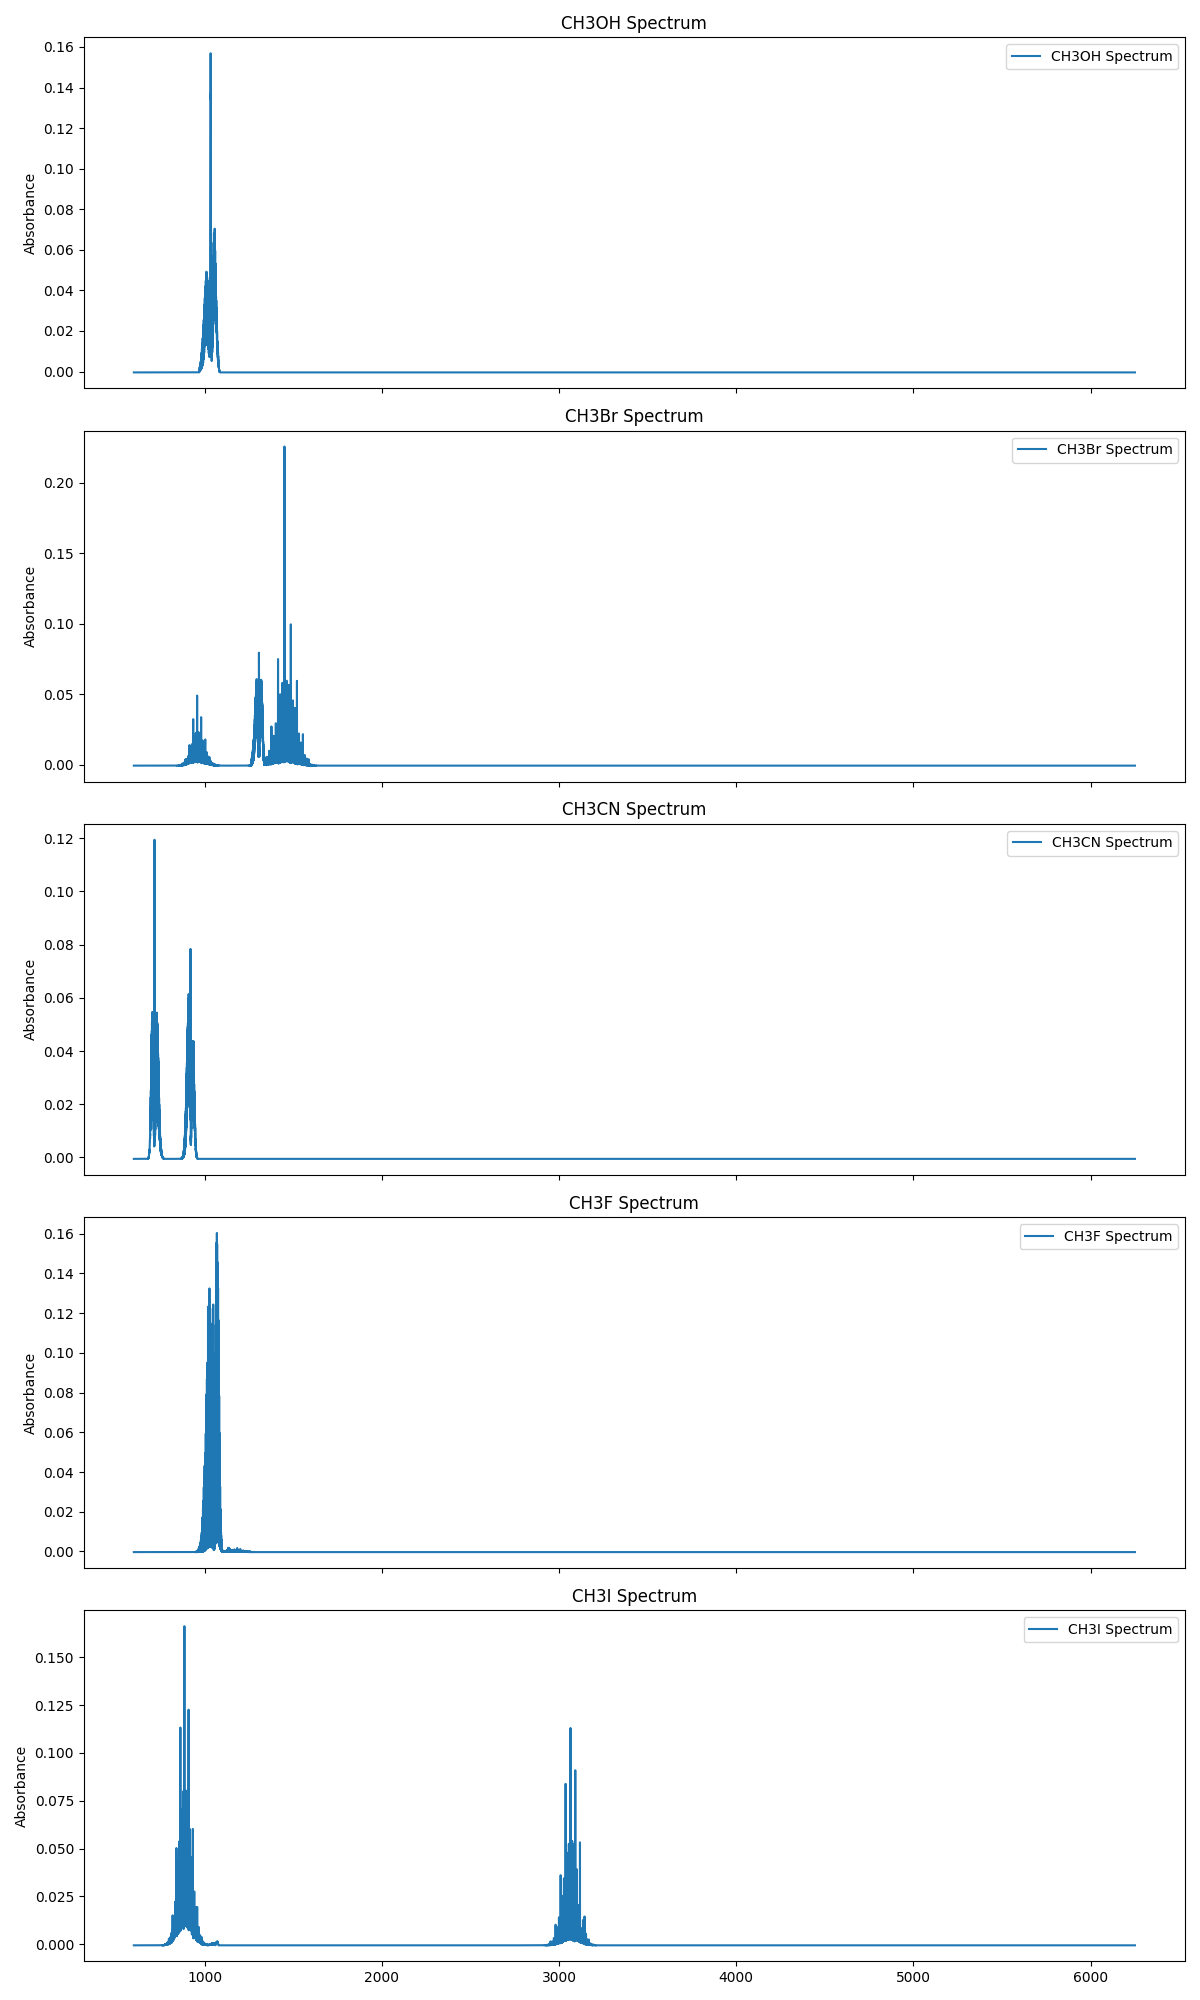

In [ ]:
fig, axs = plt.subplots(len(spectra.keys()), 1, figsize=(12, 20), sharex=True)

for i in spectra.keys():

    axs[list(spectra.keys()).index(i)].plot(spectra[i]['wavenumber'], spectra[i]['absorbance_normalized'], label=f'{i} Spectrum')
    axs[list(spectra.keys()).index(i)].set_title(f'{i} Spectrum')
    # axs[list(spectra.keys()).index(i)].set_xlabel('Wavenumber (cm ^-1)')
    axs[list(spectra.keys()).index(i)].set_ylabel('Absorbance')
    axs[list(spectra.keys()).index(i)].legend()
plt.tight_layout()


# Interpolating for overlapping peaks

In [ ]:
aligned, shifts = align_spectra_family(
    spectra,
    reference="CH3OH",
    wn_lo=900, wn_hi=1200,     # pick a band with strong shared features
    max_shift_cm1=10.0,         # allowable offset in cm^-1
    smooth_window=51,
    use_derivative=True
)

print(shifts)  # shift for each molecule in cm^-1

print(aligned)

{'CH3OH': 0.0, 'CH3Br': -3.28499999992232, 'CH3CN': -1.5089999999643169, 'CH3F': 0.3949999999906595, 'CH3I': -9.044999999786114}
{'CH3OH': {'wavenumber': array([ 900.0008,  900.0018,  900.0028, ..., 1199.9978, 1199.9988,
       1199.9998]), 'absorbance': array([-4.43050598e-05, -4.43050598e-05, -4.43050598e-05, ...,
       -4.43045129e-05, -4.43045082e-05, -4.43045034e-05]), 'shift_cm1': 0.0}, 'CH3Br': {'wavenumber': array([ 900.0008,  900.0018,  900.0028, ..., 1199.9978, 1199.9988,
       1199.9998]), 'absorbance': array([ 1.48673823e-05,  1.47838969e-05,  1.47037311e-05, ...,
       -6.68644339e-05, -6.68640361e-05, -6.68636330e-05]), 'shift_cm1': -3.28499999992232}, 'CH3CN': {'wavenumber': array([ 900.0008,  900.0018,  900.0028, ..., 1199.9978, 1199.9988,
       1199.9998]), 'absorbance': array([ 2.27245061e-03,  2.26128172e-03,  2.25018764e-03, ...,
       -5.53168378e-05, -5.53168378e-05, -5.53168378e-05]), 'shift_cm1': -1.5089999999643169}, 'CH3F': {'wavenumber': array([ 900.0008

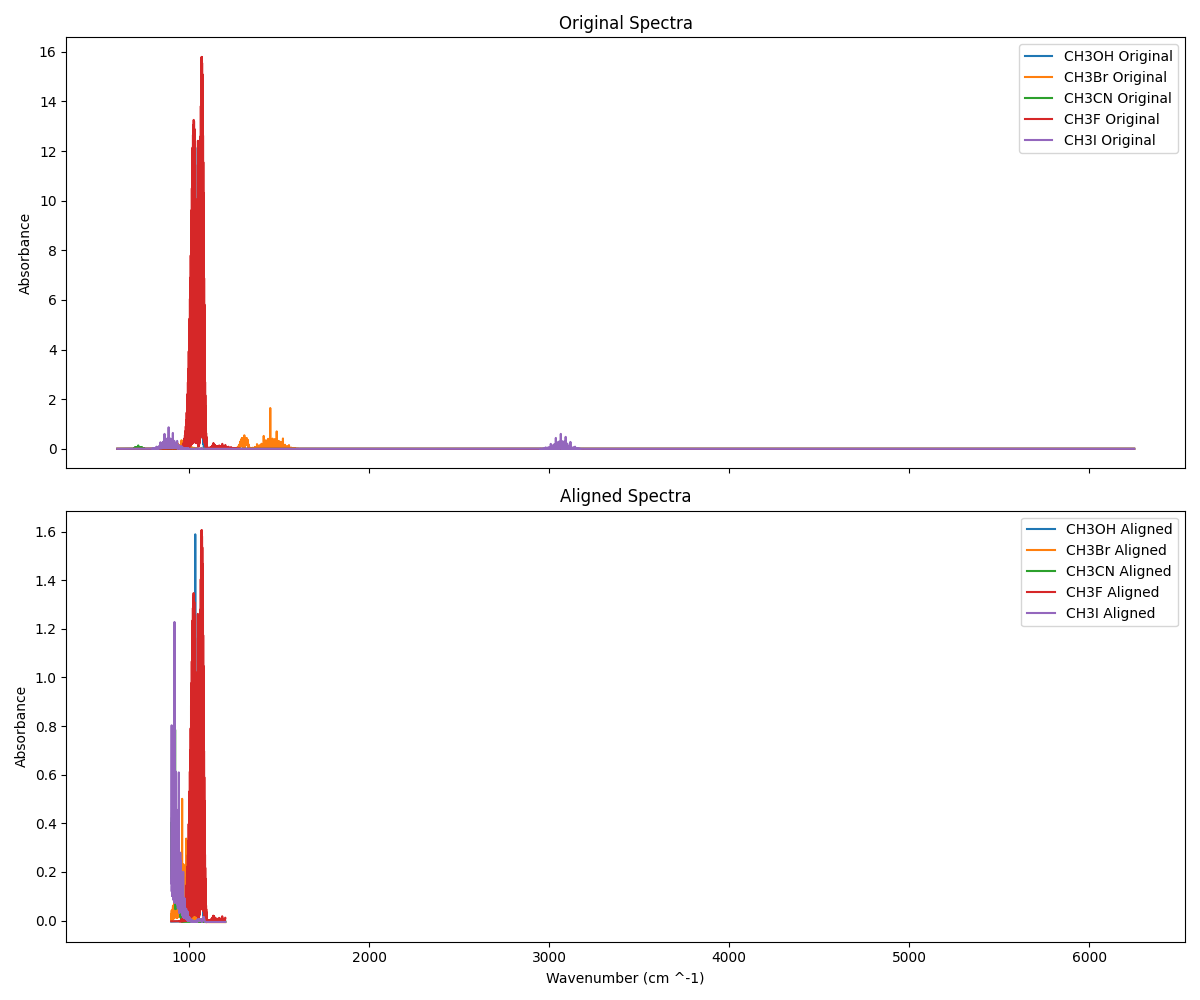

In [ ]:
fig, axs = plt.subplots(2, 1, figsize=(12, 10), sharex=True)
for i in spectra.keys():
    axs[0].plot(spectra[i]['wavenumber'], spectra[i]['absorbance'], label=f'{i} Original')
    axs[1].plot(aligned[i]['wavenumber'], aligned[i]['absorbance'], label=f'{i} Aligned')
    axs[0].set_title('Original Spectra')
    axs[1].set_title('Aligned Spectra')
    axs[1].set_xlabel('Wavenumber (cm ^-1)')
    axs[0].set_ylabel('Absorbance')
    axs[1].set_ylabel('Absorbance')
    axs[0].legend()
    axs[1].legend()
plt.tight_layout()
plt.show()

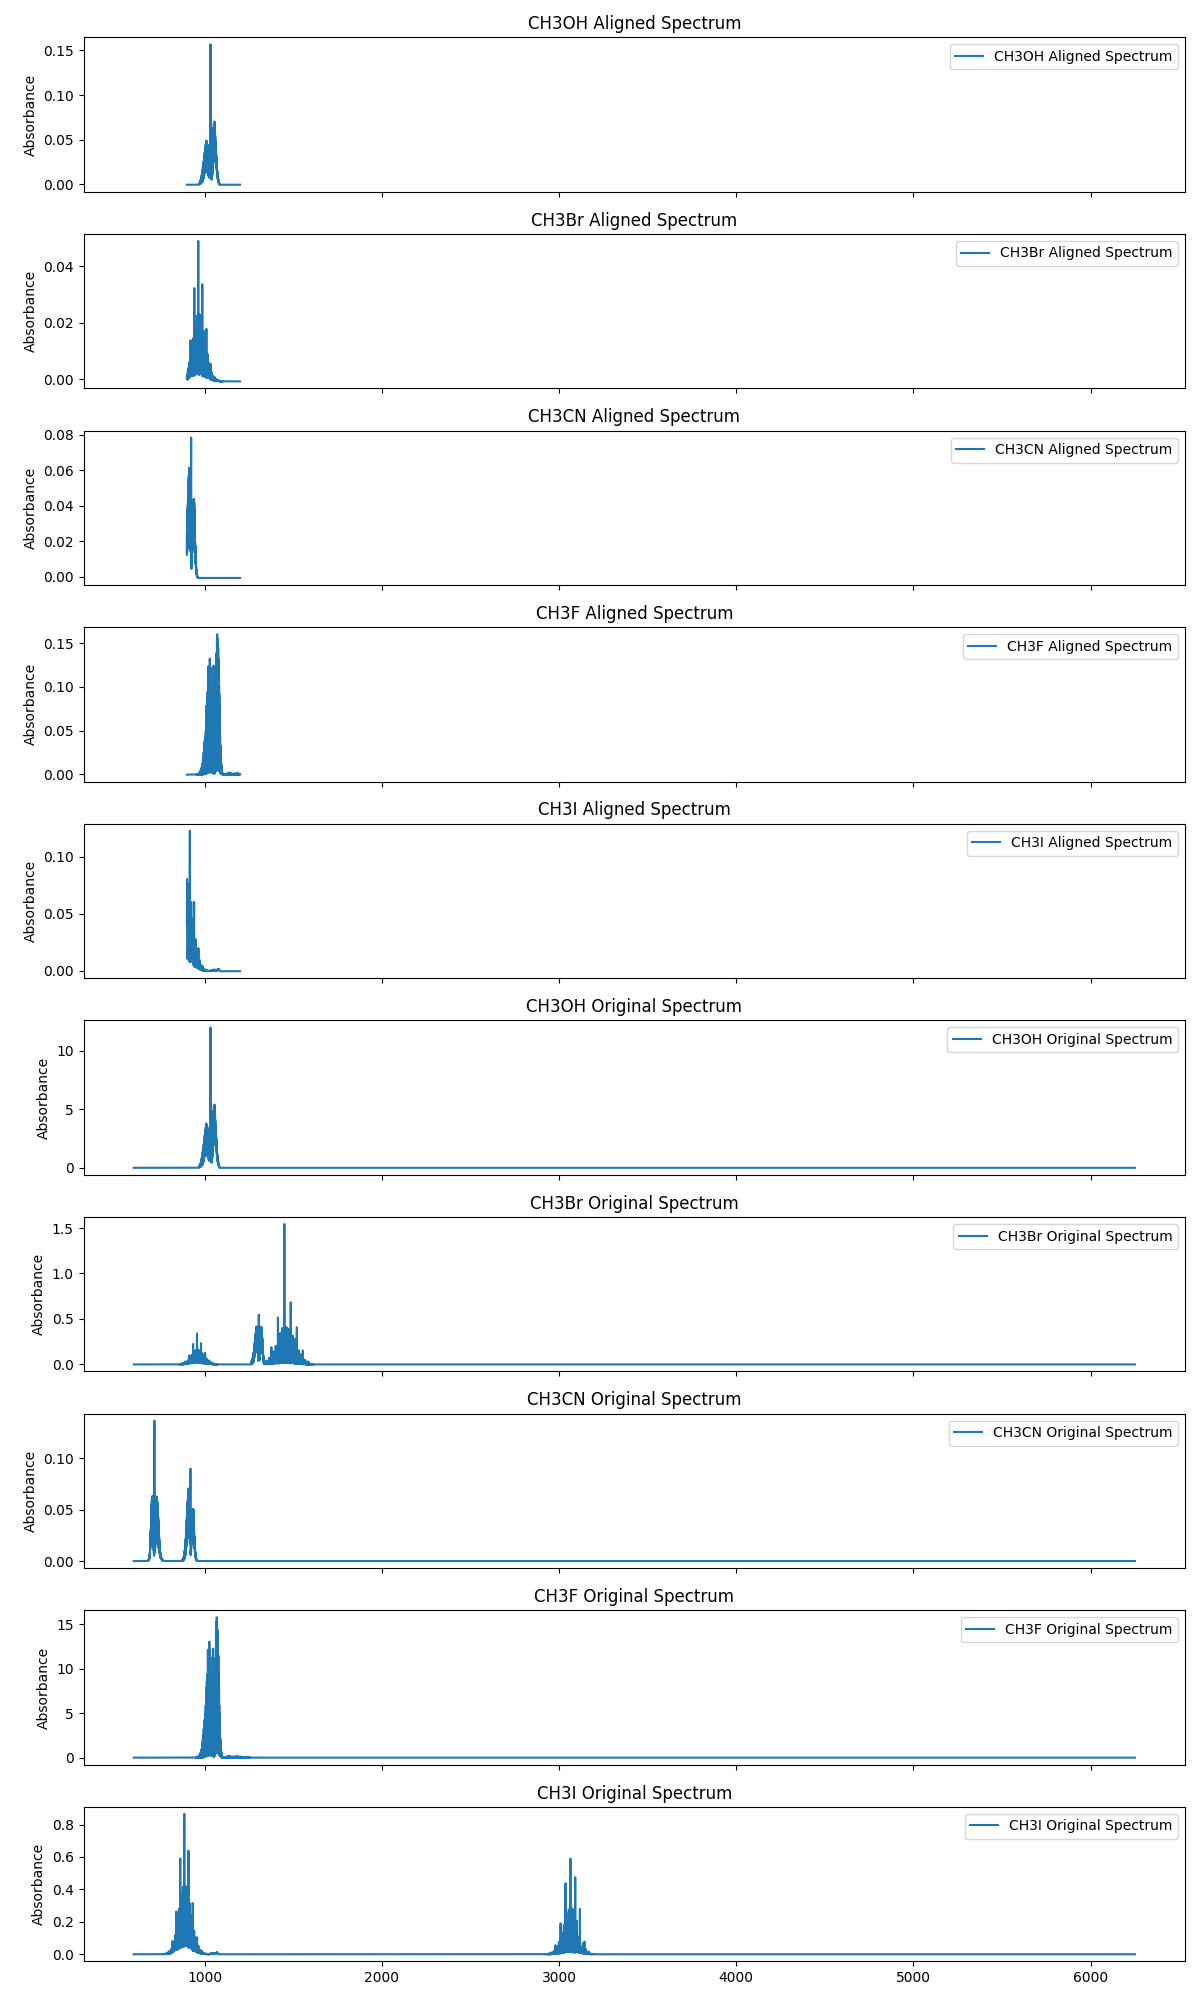

In [ ]:
fig, axs = plt.subplots(2*len(aligned.keys()), 1, figsize=(12, 20), sharex=True)
for i in aligned.keys():
    axs[list(aligned.keys()).index(i)].plot(aligned[i]['wavenumber'], aligned[i]['absorbance'], label=f'{i} Aligned Spectrum')
    axs[list(aligned.keys()).index(i)].set_title(f'{i} Aligned Spectrum')
    # axs[list(aligned.keys()).index(i)].set_xlabel('Wavenumber (cm ^-1)')
    axs[list(aligned.keys()).index(i)].set_ylabel('Absorbance')
    axs[list(aligned.keys()).index(i)].legend()

    axs[list(spectra.keys()).index(i)+len(aligned.keys())].plot(spectra[i]['wavenumber'], spectra[i]['absorbance'], label=f'{i} Original Spectrum')
    axs[list(spectra.keys()).index(i)+len(aligned.keys())].set_title(f'{i} Original Spectrum')
    axs[list(spectra.keys()).index(i)+len(aligned.keys())].set_ylabel('Absorbance')
    axs[list(spectra.keys()).index(i)+len(aligned.keys())].legend()
plt.tight_layout()
plt.show()

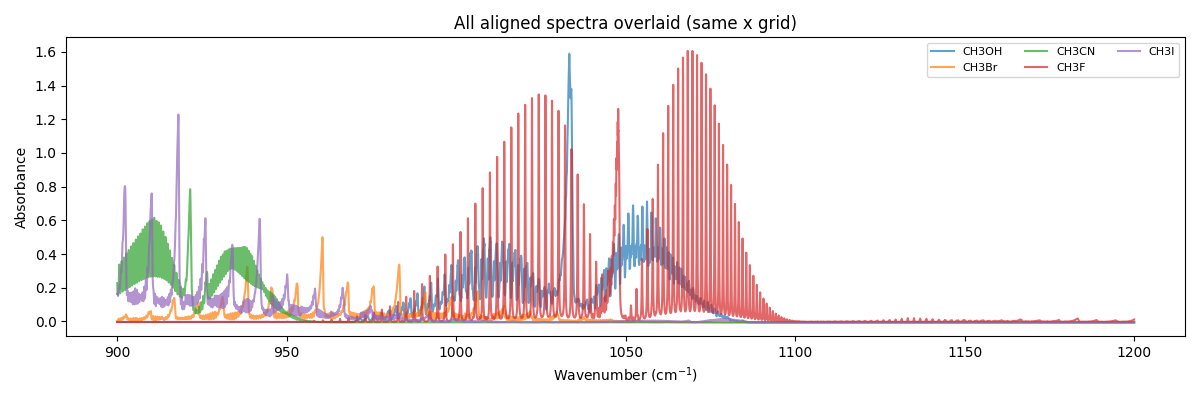

In [ ]:
ref = "CH3OH"
plt.figure(figsize=(12,4))

for mol in aligned:
    plt.plot(aligned[mol]["wavenumber"], aligned[mol]["absorbance"], alpha=0.7, label=mol)

plt.title("All aligned spectra overlaid (same x grid)")
plt.xlabel("Wavenumber (cm$^{-1}$)")
plt.ylabel("Absorbance")
plt.legend(ncol=3, fontsize=8)
plt.tight_layout()
plt.show()


CH3OH: spectral resolution = 1050000.30
CH3Br: spectral resolution = 1050000.30
CH3CN: spectral resolution = 1050000.30
CH3F: spectral resolution = 1050000.30
CH3I: spectral resolution = 1050000.30


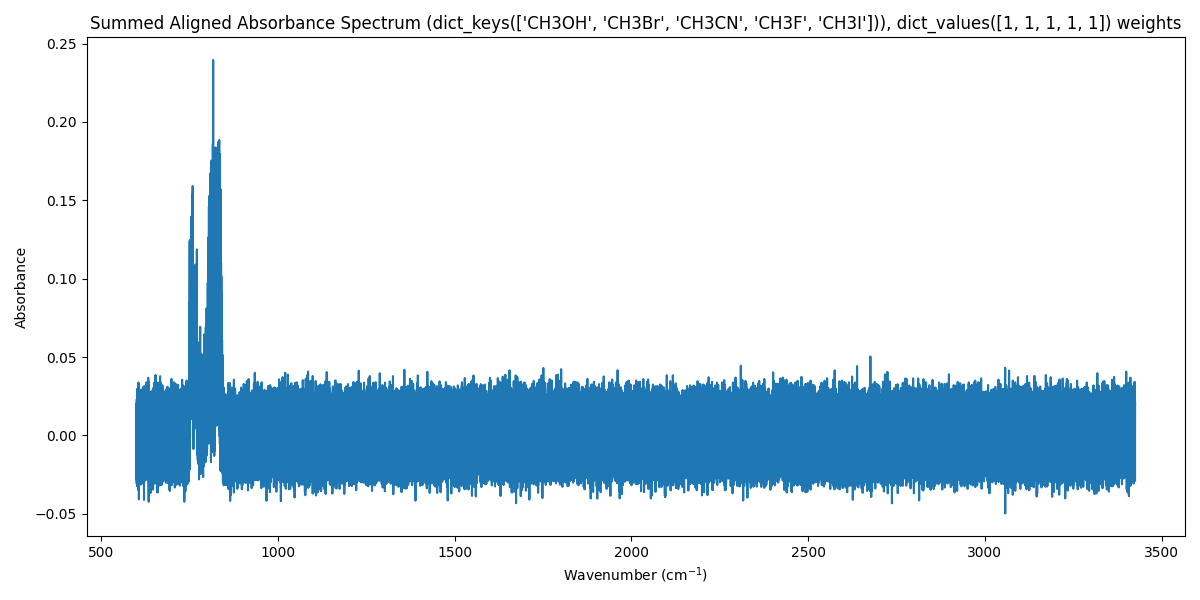

In [ ]:
molecule_weights = {
    # "SO2" : 1,
    # "SO3" : 1,
    # "H2S" : 1,
    # "OCS" : 0,
    # "CS" : 1,
    # "CS2" : 0,
    # "SO" : 1
    # "CH4": 0,
    # "C2H2" : 1,
    # "C2H6" : 1,
    # "C2H4" : 5, 
    "CH3OH" : 1, 
    "CH3Br" : 1, 
    "CH3CN" : 1, 
    # "C4H2": 0, 
    "CH3F" : 1, 
    "CH3I" : 1, 
    # "CH3" : 1
}

molecules = molecule_weights.keys()
weights = molecule_weights.values()

# === PARAMETERS ===
wl_min = 1.6                  # min wavelength in µm
wl_max = 16.6667               # max wavelength in µm

wn_min = 1e4 / wl_max         # min wavenumber in cm^-1
wn_max = 1e4 / wl_min         # max wavenumber in cm^-1
bin_width = 0.01             # bin width in cm^-1

SNR = 100                     # signal-to-noise ratio

# === OUTPUT ARRAYS ===
bin_edges = np.arange(wn_min, wn_max + bin_width, bin_width)
binned_abs = np.zeros(len(bin_edges)-1)

# === MAIN LOOP ===
for molecule in molecules:
    
    weight = molecule_weights[molecule]
    # molecule_index = molecule_indices[molecule]
    # filepath = os.path.join(data_folder, filename)

    # === PARSE FILE ===

    absorbance = aligned[molecule]['absorbance']
    wn_grid = aligned[molecule]['wavenumber']

    wn_array = np.array(wn_grid)
    absorbance = np.array(absorbance) * weight
    # print(f"{molecule}: wavenumber range = {wn_array.min():.6f} – {wn_array.max():.6f} µm")
    # print('absorbance =', absorbance)


    # === BIN BY WAVELENGTH ===
    hist, _ = np.histogram(wn_array, bins=bin_edges, weights=absorbance)
    binned_abs += hist

    resolution = wn_array / np.median(np.diff(wn_array))
    print(f"{molecule}: spectral resolution = {np.median(resolution):.2f}")

plt.figure(figsize=(12, 6))
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1])
plt.plot(bin_centers, add_poisson_noise_snr(binned_abs, SNR), label='Summed Aligned Absorbance Spectrum')
plt.title(f'Summed Aligned Absorbance Spectrum ({molecule_weights.keys()}), {molecule_weights.values()} weights')
plt.xlabel('Wavenumber (cm$^{-1}$)')
plt.ylabel('Absorbance')



# plt.legend()
plt.tight_layout()
plt.show()


# # === SAVE TO TEXT FILE ===
# output_file = "summed_spectrum.txt"
# output_data = np.column_stack((bin_centers, binned_intensity))

# np.savetxt(output_file, output_data, fmt=("%.6f,%.12e"), delimiter=' ', header="Wavenumber(cm^-1)  Intensity", comments='')

# print(f"Saved spectrum to {output_file}")


# Creating Summed Spectrum

In [ ]:
results = []

wavenumber_bins_for_loop = [1, 0.1, 0.01, 0.001]

molecule_indices = {
    # "SO": 50,
    # # "S2": 58,
    # "SO2": 9,
    # "SO3": 47,
    # "H2S": 31,
    # "OCS": 19,
    # "CS2": 53,
    # "CS": 46
    # "CH4": 6,
    # "C2H2" : 26,
    # "C2H6" : 27,
    # "C2H4" : 38, 
    "CH3OH" : 39, 
    "CH3Br" : 40, 
    "CH3CN" : 41, 
    # "C4H2": 43, 
    "CH3F" : 51, 
    "CH3I" : 54, 
    # "CH3" : 57
}

molecule_weights = {
    # "SO2" : 1,
    # "SO3" : 1,
    # "H2S" : 1,
    # "OCS" : 0,
    # "CS" : 1,
    # "CS2" : 0,
    # "SO" : 1
    # "CH4": 0,
    # "C2H2" : 1,
    # "C2H6" : 1,
    # "C2H4" : 5, 
    "CH3OH" : 1, 
    "CH3Br" : 1, 
    "CH3CN" : 1, 
    # "C4H2": 0, 
    "CH3F" : 1, 
    "CH3I" : 1, 
    # "CH3" : 1
}

snr_to_test = [1,5,10,50,100,500,1000]

# === PARAMETERS ===
wl_min = 1.6                  # min wavelength in µm
wl_max = 16.6667               # max wavelength in µm

wn_min = 1e4 / wl_max         # min wavenumber in cm^-1
wn_max = 1e4 / wl_min         # max wavenumber in cm^-1

for i in range(len(wavenumber_bins_for_loop)):

    #Parsing Data________________________________________________________________________________________________________________________________________________
    wavenumber_bin = wavenumber_bins_for_loop[i]
    print(f'Wavenumber bin size: {wavenumber_bin} cm^-1')

    spectra = generate_absorbance_library(
    molecule_indices,
    lam_min_um=1.6,
    lam_max_um=16.6667, dwn=wavenumber_bin);

    for mol in spectra.keys():
        print(mol, 'dwn actual = ', np.median(np.diff(spectra[mol]['wavenumber'])))
        spectra[mol]['absorbance_normalized'] = normalize_spectrum(
            spectra[mol]['absorbance']
        )

    #Aligning Spectra______________________________________________________________________________________________________________________________

    wn_lo, wn_hi = 900, 1200

    aligned, shifts = align_spectra_family(
        spectra,
        reference="CH3OH",
        wn_lo=wn_lo, wn_hi=wn_hi,     # pick a band with strong shared features
        max_shift_cm1=10.0,         # allowable offset in cm^-1
        smooth_window=51,
        use_derivative=True
    )

    #Creating Summed Spectrum______________________________________________________________________________________________________________________________

    bin_width = wavenumber_bin             # bin width in cm^-1

    # === OUTPUT ARRAYS ===
    bin_edges = np.arange(wn_lo, wn_hi + bin_width, bin_width)
    binned_abs = np.zeros(len(bin_edges)-1)

    molecules = list(molecule_weights.keys())
    weights = molecule_weights  # dict
    weight = weights[molecule]

    resolution_median_by_molecule = {}

    # === MAIN LOOP ===
    for molecule in molecules:
        
        weight = molecule_weights[molecule]
        # molecule_index = molecule_indices[molecule]
        # filepath = os.path.join(data_folder, filename)

        # === PARSE FILE ===

        absorbance = aligned[molecule]['absorbance']
        wn_grid = aligned[molecule]['wavenumber']

        wn_array = np.array(wn_grid)
        absorbance = np.array(absorbance) * weight
        print(f"{molecule}: wavenumber range = {wn_array.min():.6f} – {wn_array.max():.6f} µm")
        print('absorbance =', absorbance)

        # === BIN BY WAVELENGTH ===
        hist, _ = np.histogram(wn_array, bins=bin_edges, weights=absorbance)
        binned_abs += hist

        resolution = wn_array / np.median(np.diff(wn_array))
        resolution_median_by_molecule[molecule] = np.median(resolution)
        print(f"{molecule}: spectral resolution = {np.median(resolution):.2f}")

    #Apply Poisson Noise______________________________________________________________________________________________________________________________

    for snr in snr_to_test:
        print(f'Adding Poisson noise to summed spectrum with SNR = {snr}')
        summed_abs_noisy = add_poisson_noise_snr(binned_abs, snr)
        summed_abs_noisy_normalized = normalize_spectrum(summed_abs_noisy)

        # plt.figure(figsize=(10, 6))
        # plt.plot(bin_centers, summed_abs_noisy)
        # plt.xlabel("Wavelength (µm)")
        # plt.ylabel("Weighted Intensity with Poisson Noise")
        # plt.title(f"Summed Sulfur Compound Spectra with Poisson Noise (SNR={snr}) ({', '.join(molecules)}), ({', '.join([str(w) for w in weights])}) Respectively")
        # plt.show()

        #Store Noisy Spectra______________________________________________________________________________________________________________________________

        for i in range(len(molecules)):
            molecule = list(molecules)[i]
            print(f'Adding Poisson noise to {molecule} spectrum with SNR = {snr}')
            aligned[molecule][f'spectrum_noisy'] = add_poisson_noise_snr(aligned[molecule]['absorbance'], snr)


        max_shift_cm1 = 2
        max_shift_summed = int(max_shift_cm1/ wavenumber_bin)  # maximum shift, physically motivated

        for i in range(len(molecules)):
            molecule = list(molecules)[i]
            weight = list(weights)[i]
            cross_correlation_vector_summed = correlate(summed_abs_noisy_normalized, normalize_spectrum(aligned[molecule][f'spectrum_noisy']), mode='full')    
            lags_summed = signal.correlation_lags(len(summed_abs_noisy_normalized), len(aligned[molecule][f'spectrum_noisy']), mode='full')
            lag_0_summed = len(summed_abs_noisy_normalized) - 1
            
            mask_summed = np.abs(lags_summed) <= max_shift_summed  
            similarity_summed = np.max(cross_correlation_vector_summed[mask_summed])
            aligned[molecule][f'similarity_summed_noisy_snr_{snr}'] = similarity_summed
            aligned[molecule][f'cross_correlation_vector_summed_noisy_snr_{snr}'] = cross_correlation_vector_summed
            aligned[molecule][f'lags_summed_snr_{snr}'] = lags_summed
            aligned[molecule][f'SNR_summed_noisy_snr_{snr}'] = similarity_summed / np.std(aligned[molecule][f'cross_correlation_vector_summed_noisy_snr_{snr}'][mask_summed])

            results.append({
                'molecule': molecule,
                'wavenumber_bin': wavenumber_bin,
                'Resolution' : resolution_median_by_molecule[molecule],
                'weight': weight,
                'input snr': snr,
                'similarity_summed_noisy': similarity_summed,
                'similarity_snr': aligned[molecule][f'SNR_summed_noisy_snr_{snr}'],
                'summed_abs_noisy': summed_abs_noisy
            })

            # print(f'{molecule} Similarity (summed noisy SNR={snr}, weight={weight}): ', similarity_summed, "SNR: ", aligned[molecule][f'SNR_summed_noisy_snr_{snr}'])

    


Wavenumber bin size: 1 cm^-1


NameError: name 'generate_absorbance_library' is not defined

In [ ]:
df = pd.DataFrame(results)
df

,molecule,wavenumber_bin,Resolution,weight,input snr,similarity_summed_noisy,similarity_snr,summed_abs_noisy
0,CH3OH,1.000,1.050499e+03,CH3OH,1,6566.671602,11.015084,"[18.298316740372254, 9.750070667212931, 21.365..."
1,CH3Br,1.000,1.050499e+03,CH3Br,1,1050.792104,3.910803,"[18.298316740372254, 9.750070667212931, 21.365..."
2,CH3CN,1.000,1.050499e+03,CH3CN,1,3502.787717,9.330989,"[18.298316740372254, 9.750070667212931, 21.365..."
3,CH3F,1.000,1.050499e+03,CH3F,1,6663.777119,4.256997,"[18.298316740372254, 9.750070667212931, 21.365..."
4,CH3I,1.000,1.050499e+03,CH3I,1,3501.605962,7.890363,"[18.298316740372254, 9.750070667212931, 21.365..."
...,...,...,...,...,...,...,...,...
135,CH3OH,0.001,1.050000e+06,CH3OH,1000,5756.515985,13.345552,"[0.3862514804527569, 0.3847233442991464, 0.384..."
136,CH3Br,0.001,1.050000e+06,CH3Br,1000,2141.578704,7.701154,"[0.3862514804527569, 0.3847233442991464, 0.384..."
137,CH3CN,0.001,1.050000e+06,CH3CN,1000,4210.114266,27.020392,"[0.3862514804527569, 0.3847233442991464, 0.384..."
138,CH3F,0.001,1.050000e+06,CH3F,1000,6365.913700,5.916178,"[0.3862514804527569, 0.3847233442991464, 0.384..."


In [ ]:
df = pd.read_csv('/Users/zaniaccollins/Desktop/SGL/Figures/DistinguishingMoleculesInClasses/mock_spectra/mock_spectra_normalize_test.csv')
df

,molecule,wavenumber_bin,Resolution,weight,input snr,similarity_summed_noisy,similarity_snr
0,CH3OH,1.000,1.050499e+03,CH3OH,1,0.080635,1.240521
1,CH3Br,1.000,1.050499e+03,CH3Br,1,0.059184,1.120205
2,CH3CN,1.000,1.050499e+03,CH3CN,1,0.152375,2.773090
3,CH3F,1.000,1.050499e+03,CH3F,1,0.051245,0.964791
4,CH3I,1.000,1.050499e+03,CH3I,1,0.117952,2.656612
...,...,...,...,...,...,...,...
135,CH3OH,0.001,1.050000e+06,CH3OH,1000,0.466911,13.301511
136,CH3Br,0.001,1.050000e+06,CH3Br,1000,0.082404,7.704338
137,CH3CN,0.001,1.050000e+06,CH3CN,1000,0.303153,27.267850
138,CH3F,0.001,1.050000e+06,CH3F,1000,0.522998,5.907445
